In [51]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
import logging

logging.basicConfig(
    level=logging.DEBUG,
    format="%(name)s — %(levelname)s: %(message)s",
    force=True,           # critical in Jupyter
)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

# make ai_playground importable when running from this notebook's directory
sys.path.insert(0, str(pathlib.Path("../..").resolve()))

from ai_playground.perceptron import Perceptron

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example 1 — AND gate (linearly separable)

In [52]:
def run_and(bipolar: bool = False):
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    neg = -1 if bipolar else 0
    y = np.array([neg, neg, neg, 1])

    p = Perceptron(learning_rate=0.1, bipolar=bipolar)
    p.train(X, y)

    print(f"  bipolar={bipolar}")
    print(f"  Weights: {p.weights}  Bias: {p.bias}")
    print(f"  Predictions: {p.predict(X)}")
    print(f"  Expected:    {y}")

In [53]:
for bipolar in (False, True):
    print(f"Run AND bipolar={bipolar}")
    run_and(bipolar)

ai_playground.perceptron.perceptron — DEBUG: Sample: [0 0], Label: 0, Weights: [0. 0.], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 1], Label: 0, Weights: [0. 0.], Bias: -0.1 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 0], Label: 0, Weights: [0. 0.], Bias: -0.1 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 1], Label: 1, Weights: [0. 0.], Bias: -0.1 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Weights after epoch 1: [0.1 0.1], bias: 0.0000, errors: 2
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 0], Label: 0, Weights: [0.1 0.1], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 1], Label: 0, Weights: [0.1 0.1], Bias: -0.1 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 0], Label: 0, Weights: [0.1 0. ], Bias: -0.2 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 1], Label: 1, Weights: [0.1 0. ], Bias: -0.2 z: -0.1
ai_playground.perceptron.perceptron — 

Run AND bipolar=False
  bipolar=False
  Weights: [0.2 0.1]  Bias: -0.20000000000000004
  Predictions: [0 0 0 1]
  Expected:    [0 0 0 1]
Run AND bipolar=True
  bipolar=True
  Weights: [0.4 0.2]  Bias: -0.4000000000000001
  Predictions: [-1 -1 -1  1]
  Expected:    [-1 -1 -1  1]


## Example 2 — 2D linearly separable data with decision boundary plot

In [54]:
def run_2d_clusters(bipolar: bool = False):
    rng = np.random.default_rng(42)
    X0 = rng.normal(loc=[1, 1], scale=0.5, size=(50, 2))
    X1 = rng.normal(loc=[3, 3], scale=0.5, size=(50, 2))
    X = np.vstack([X0, X1])
    neg = -1 if bipolar else 0
    y = np.array([neg] * 50 + [1] * 50)

    p = Perceptron(learning_rate=0.1, bipolar=bipolar)
    p.train(X, y)

    acc = np.mean(p.predict(X) == y)
    print(f"bipolar={bipolar}  Accuracy: {acc:.0%}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(*X0.T, label=f"Class {neg}", alpha=0.7)
    ax.scatter(*X1.T, label="Class 1", alpha=0.7)

    w0, w1 = p.weights
    xs = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
    ax.plot(xs, -(w0 * xs + p.bias) / w1, "b--", label="Decision boundary")

    ax.legend()
    ax.set_title(f"Perceptron — 2D data  (bipolar={bipolar})")
    plt.tight_layout()
    plt.show()

ai_playground.perceptron.perceptron — DEBUG: Sample: [1.15235854 0.48000795], Label: 0, Weights: [0. 0.], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.3752256  1.47028236], Label: 0, Weights: [-0.11523585 -0.04800079], Bias: -0.1 z: -0.3290500178092529
ai_playground.perceptron.perceptron — DEBUG: Sample: [0.02448241 0.34891025], Label: 0, Weights: [-0.11523585 -0.04800079], Bias: -0.1 z: -0.11956922003549317
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.0639202 0.8418787], Label: 0, Weights: [-0.11523585 -0.04800079], Bias: -0.1 z: -0.2630125998189165
ai_playground.perceptron.perceptron — DEBUG: Sample: [0.99159942 0.57347804], Label: 0, Weights: [-0.11523585 -0.04800079], Bias: -0.1 z: -0.2417952075955606
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.43969899 1.38889597], Label: 0, Weights: [-0.11523585 -0.04800079], Bias: -0.1 z: -0.3325730524911362
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.03301535 1.5636206 ], Label: 0, 

Run linearly separable bipolar=False


ai_playground.perceptron.perceptron — DEBUG: Sample: [1.23375467 0.57035377], Label: 0, Weights: [-0.13188138  0.37204775], Bias: -0.6 z: -0.5505104328521473
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.18437539 0.5205587 ], Label: 0, Weights: [-0.13188138  0.37204775], Bias: -0.6 z: -0.5625243688213639
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.43922515 0.97503704], Label: 0, Weights: [-0.13188138  0.37204775], Bias: -0.6 z: -0.4270466600479188
ai_playground.perceptron.perceptron — DEBUG: Sample: [0.90756882 0.65953523], Label: 0, Weights: [-0.13188138  0.37204775], Bias: -0.6 z: -0.4743128302631155
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.61127067 0.92273526], Label: 0, Weights: [-0.13188138  0.37204775], Bias: -0.6 z: -0.4691950226088657
ai_playground.perceptron.perceptron — DEBUG: Sample: [0.78583609 0.82393322], Label: 0, Weights: [-0.13188138  0.37204775], Bias: -0.6 z: -0.39709464428941377
ai_playground.perceptron.perceptron — DEBUG: Sample

bipolar=False  Accuracy: 100%


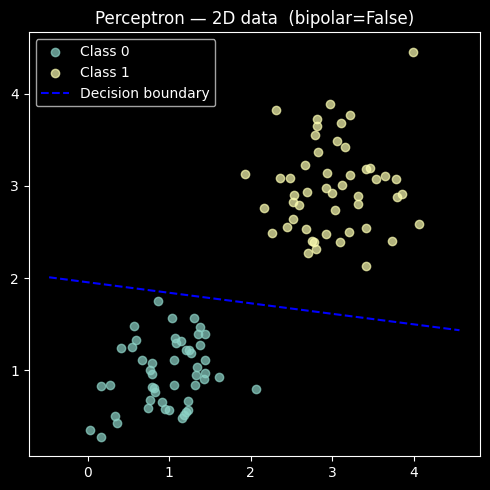

ai_playground.perceptron.perceptron — DEBUG: Sample: [1.15235854 0.48000795], Label: -1, Weights: [0. 0.], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.3752256  1.47028236], Label: -1, Weights: [-0.23047171 -0.09600159], Bias: -0.2 z: -0.6581000356185058
ai_playground.perceptron.perceptron — DEBUG: Sample: [0.02448241 0.34891025], Label: -1, Weights: [-0.23047171 -0.09600159], Bias: -0.2 z: -0.23913844007098634
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.0639202 0.8418787], Label: -1, Weights: [-0.23047171 -0.09600159], Bias: -0.2 z: -0.526025199637833
ai_playground.perceptron.perceptron — DEBUG: Sample: [0.99159942 0.57347804], Label: -1, Weights: [-0.23047171 -0.09600159], Bias: -0.2 z: -0.4835904151911212
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.43969899 1.38889597], Label: -1, Weights: [-0.23047171 -0.09600159], Bias: -0.2 z: -0.6651461049822724
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.03301535 1.5636206 ], Label

Run linearly separable bipolar=True


ai_playground.perceptron.perceptron — DEBUG: Sample: [3.99836545 4.45693123], Label: 1, Weights: [0.24063266 0.94475538], Bias: -0.6000000000000001 z: 4.572847089695786
ai_playground.perceptron.perceptron — DEBUG: Sample: [3.20720472 2.50523094], Label: 1, Weights: [0.24063266 0.94475538], Bias: -0.6000000000000001 z: 2.5385886191663105
ai_playground.perceptron.perceptron — DEBUG: Sample: [1.93397686 3.13385573], Label: 1, Weights: [0.24063266 0.94475538], Bias: -0.6000000000000001 z: 2.8261050702940556
ai_playground.perceptron.perceptron — DEBUG: Sample: [2.59352945 2.79232137], Label: 1, Weights: [0.24063266 0.94475538], Bias: -0.6000000000000001 z: 2.662148537862234
ai_playground.perceptron.perceptron — DEBUG: Sample: [2.6939516  2.92960456], Label: 1, Weights: [0.24063266 0.94475538], Bias: -0.6000000000000001 z: 2.816012416392875
ai_playground.perceptron.perceptron — DEBUG: Sample: [3.53299012 3.07852428], Label: 1, Weights: [0.24063266 0.94475538], Bias: -0.6000000000000001 z: 3.

bipolar=True  Accuracy: 100%


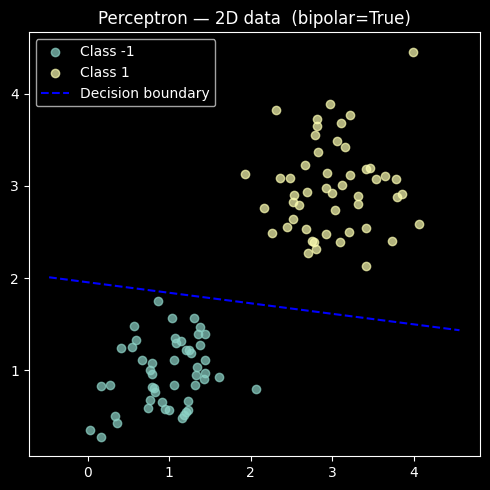

In [55]:
for bipolar in (False, True):
    print(f"Run linearly separable bipolar={bipolar}")
    run_2d_clusters(bipolar)

## Example 3 — XOR gate (not linearly separable)

XOR cannot be solved by a single perceptron — the classes have no linear decision boundary.
We enable logging so the convergence warning is visible.

In [56]:
def run_xor(bipolar: bool = False):
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    neg = -1 if bipolar else 0
    y = np.array([neg, 1, 1, neg])  # XOR truth table

    p = Perceptron(learning_rate=0.1, max_epochs=10, bipolar=bipolar)
    p.train(X, y)

    preds = p.predict(X)
    print(f"  bipolar={bipolar}")
    print(f"  Predictions: {preds}")
    print(f"  Expected:    {y}")
    print(f"  Accuracy:    {np.mean(preds == y):.0%}")

    fig, ax = plt.subplots(figsize=(4, 4))
    for (x0, x1), label in zip(X, y):
        ax.scatter(x0, x1, marker=("^" if label > 0 else "o"), s=150,
                   color=("tab:orange" if label > 0 else "tab:blue"))

    w0, w1 = p.weights
    xs = np.array([-0.5, 1.5])
    ys = np.array([-0.5, 1.5])
    if abs(w1) > 1e-9:          # typical case: solve for y
        ax.plot(xs, -(w0 * xs + p.bias) / w1, "b--", label="Learned boundary")
    elif abs(w0) > 1e-9:        # vertical line: solve for x
        x_vert = -p.bias / w0
        ax.axvline(x_vert, color="b", linestyle="--", label="Learned boundary")
    else:                        # degenerate: all-zero weights, nothing to draw
        ax.text(0.5, 0.5, "no boundary\n(zero weights)", ha="center",
                transform=ax.transAxes)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"XOR — no linear solution  (bipolar={bipolar})")
    ax.legend()
    plt.tight_layout()
    plt.show()

ai_playground.perceptron.perceptron — DEBUG: Sample: [0 0], Label: 0, Weights: [0. 0.], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 1], Label: 1, Weights: [0. 0.], Bias: -0.1 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 0], Label: 1, Weights: [0.  0.1], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 1], Label: 0, Weights: [0.  0.1], Bias: 0.0 z: 0.1
ai_playground.perceptron.perceptron — DEBUG: Weights after epoch 1: [-0.1  0. ], bias: -0.1000, errors: 3
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 0], Label: 0, Weights: [-0.1  0. ], Bias: -0.1 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 1], Label: 1, Weights: [-0.1  0. ], Bias: -0.1 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 0], Label: 1, Weights: [-0.1  0.1], Bias: 0.0 z: -0.1
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 1], Label: 0, Weights: [0.  0.1], Bias: 0.1 z: 0.2
ai_playground.perceptron.perc

  bipolar=False
  Predictions: [1 1 0 0]
  Expected:    [0 1 1 0]
  Accuracy:    50%


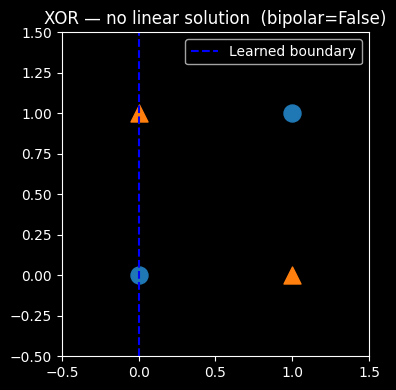

ai_playground.perceptron.perceptron — DEBUG: Sample: [0 0], Label: -1, Weights: [0. 0.], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 1], Label: 1, Weights: [0. 0.], Bias: -0.2 z: -0.2
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 0], Label: 1, Weights: [0.  0.2], Bias: 0.0 z: 0.0
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 1], Label: -1, Weights: [0.  0.2], Bias: 0.0 z: 0.2
ai_playground.perceptron.perceptron — DEBUG: Weights after epoch 1: [-0.2  0. ], bias: -0.2000, errors: 3
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 0], Label: -1, Weights: [-0.2  0. ], Bias: -0.2 z: -0.2
ai_playground.perceptron.perceptron — DEBUG: Sample: [0 1], Label: 1, Weights: [-0.2  0. ], Bias: -0.2 z: -0.2
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 0], Label: 1, Weights: [-0.2  0.2], Bias: 0.0 z: -0.2
ai_playground.perceptron.perceptron — DEBUG: Sample: [1 1], Label: -1, Weights: [0.  0.2], Bias: 0.2 z: 0.4
ai_playground.perceptron.

  bipolar=True
  Predictions: [ 1  1 -1 -1]
  Expected:    [-1  1  1 -1]
  Accuracy:    50%


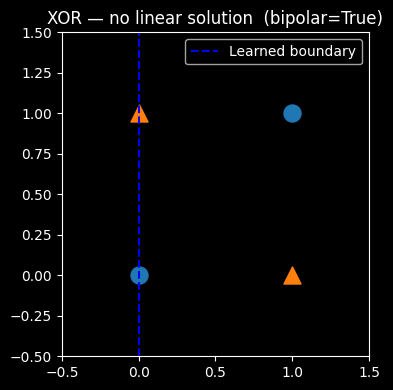

In [57]:
for bipolar in (False, True):
    run_xor(bipolar)

## Example 4 — Convergence proof visualized

The **Perceptron Convergence Theorem** guarantees that on linearly separable data the algorithm makes a *finite* number of mistakes, bounded by:

$$\text{mistakes} \leq \left(\frac{R}{\gamma}\right)^2$$

where:
- $\gamma$ = geometric margin — the minimum signed distance from any point to the true separating hyperplane (with respect to a **unit** weight vector $w^*$): $\gamma = \min_i \, y_i (w^* \cdot x_i)$
- $R$ = maximum input norm: $R = \max_i \|x_i\|$

We generate data with a **known** $\gamma$ and $R$, run the perceptron, and confirm the bound holds.

In [58]:
def run_convergence_proof(gamma=0.25, R=1.0, n_samples=200, seed=42):
    """
    Generate 2D data with true separator w*=[1,0] (the y-axis).
    Points are drawn uniformly from a disk of radius R and filtered
    so that |x[0]| >= gamma, guaranteeing margin >= gamma w.r.t. w*.

    Runs the perceptron (lr=1, bipolar ±1) and checks that the total
    number of weight updates (mistakes) is <= (R/gamma)^2.
    """
    rng = np.random.default_rng(seed)

    # Sample from disk of radius R, keep only points outside margin band
    pts = []
    while len(pts) < n_samples:
        batch = rng.uniform(-R, R, size=(n_samples * 6, 2))
        batch = batch[np.linalg.norm(batch, axis=1) <= R]       # inside disk
        batch = batch[np.abs(batch[:, 0]) >= gamma]              # outside margin
        pts.extend(batch.tolist())

    X = np.array(pts[:n_samples])
    y = np.sign(X[:, 0]).astype(int)                            # ±1 via true w*=[1,0]

    # Empirical R and gamma from this dataset
    R_emp     = np.max(np.linalg.norm(X, axis=1))
    gamma_emp = np.min(np.abs(X[:, 0]))                         # = min_i y_i(w*·x_i)
    bound     = (R_emp / gamma_emp) ** 2

    # --- Perceptron training (lr=1, standard proof form) ---
    w = np.zeros(2)
    b = 0.0
    epochs_mistakes = []

    for _ in range(1000):
        count = 0
        for xi, yi in zip(X, y):
            if yi * (xi @ w + b) <= 0:          # mistake (includes ties)
                w += yi * xi
                b += yi
                count += 1
        epochs_mistakes.append(count)
        if count == 0:
            break                                # converged

    total_mistakes = sum(epochs_mistakes)
    converged_epoch = len(epochs_mistakes)

    # --- Plot ---
    fig, (ax_data, ax_conv) = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left: scatter + margin bands + learned boundary
    ax_data.scatter(X[y == 1,  0], X[y == 1,  1], alpha=0.4, label="y = +1")
    ax_data.scatter(X[y == -1, 0], X[y == -1, 1], alpha=0.4, label="y = −1")
    ax_data.axvline( gamma_emp, color="gray", lw=1, linestyle=":", label=f"margin ±γ={gamma_emp:.3f}")
    ax_data.axvline(-gamma_emp, color="gray", lw=1, linestyle=":")
    w0, w1 = w
    xs = np.array([-R_emp, R_emp])
    if abs(w1) > 1e-9:
        ax_data.plot(xs, -(w0 * xs + b) / w1, "k--", lw=1.5, label="Learned boundary")
    elif abs(w0) > 1e-9:
        ax_data.axvline(-b / w0, color="k", linestyle="--", lw=1.5, label="Learned boundary")
    ax_data.set_aspect("equal")
    ax_data.set_xlim(-R_emp * 1.05, R_emp * 1.05)
    ax_data.set_ylim(-R_emp * 1.05, R_emp * 1.05)
    ax_data.legend(fontsize=8)
    ax_data.set_title(f"Data  (γ={gamma_emp:.3f}, R={R_emp:.3f})")

    # Right: mistakes per epoch, annotated with total vs bound
    epochs = np.arange(1, converged_epoch + 1)
    ax_conv.bar(epochs, epochs_mistakes, color="steelblue", label="Mistakes per epoch")
    ax_conv.axhline(bound, color="red", linestyle="--",
                    label=f"$(R/γ)^2 = {bound:.1f}$")
    ax_conv.annotate(f"total = {total_mistakes}", xy=(0.97, 0.97),
                     xycoords="axes fraction", ha="right", va="top", fontsize=10,
                     color="steelblue")
    ax_conv.set_xlabel("Epoch")
    ax_conv.set_ylabel("Mistakes")
    ax_conv.set_title(f"Convergence  ({total_mistakes} mistakes ≤ {bound:.1f})")
    ax_conv.legend()

    plt.suptitle(f"Perceptron Convergence  (γ={gamma}, R={R})", fontsize=12)
    plt.tight_layout()
    plt.show()

    return total_mistakes, bound

γ = 0.5


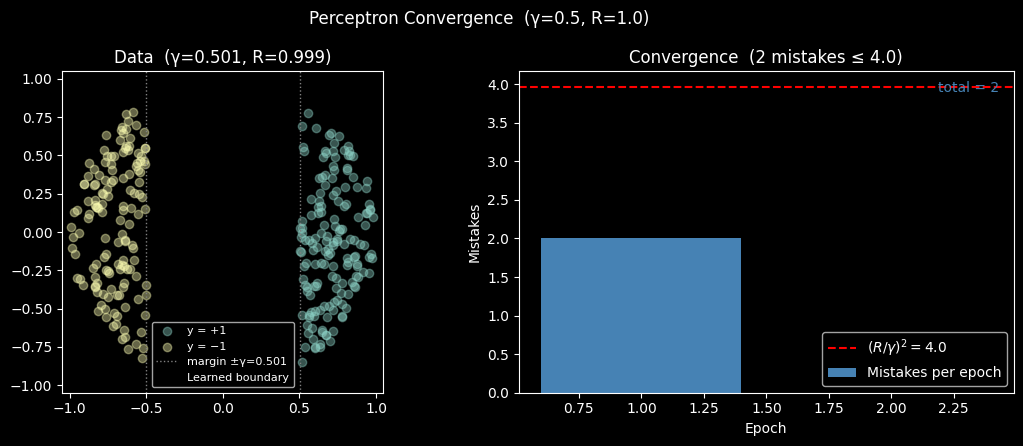


γ = 0.25


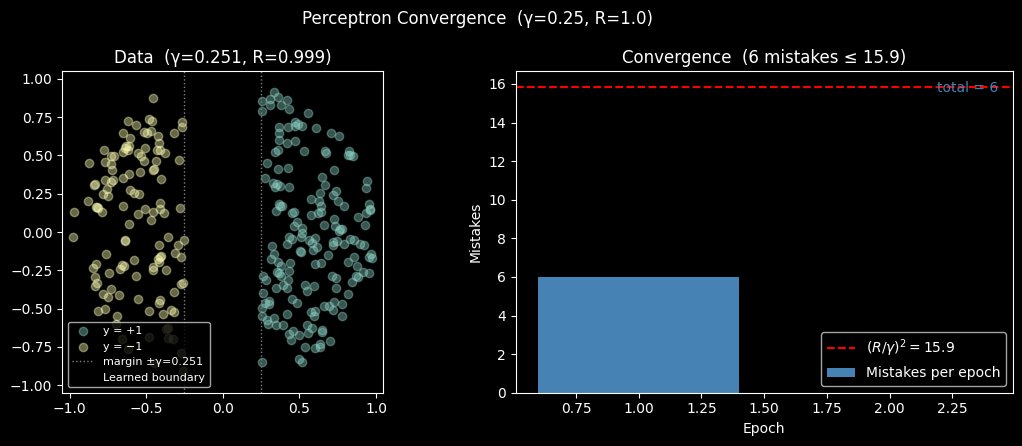


γ = 0.1


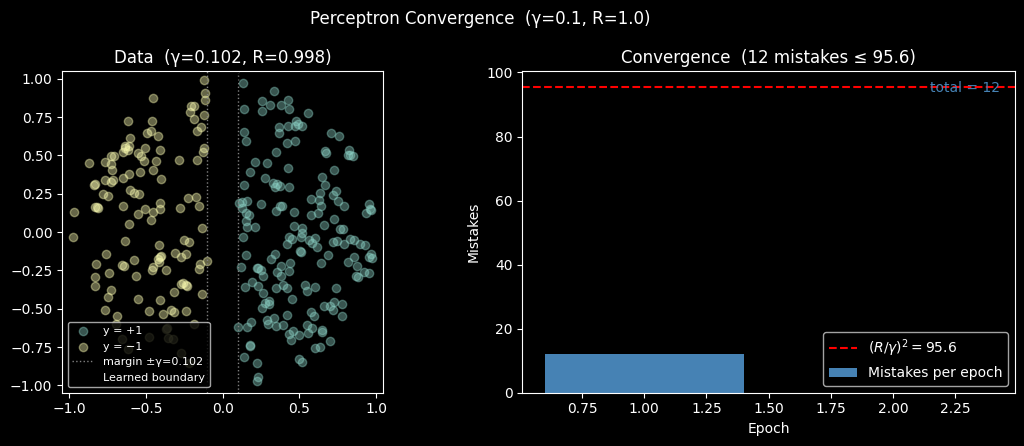

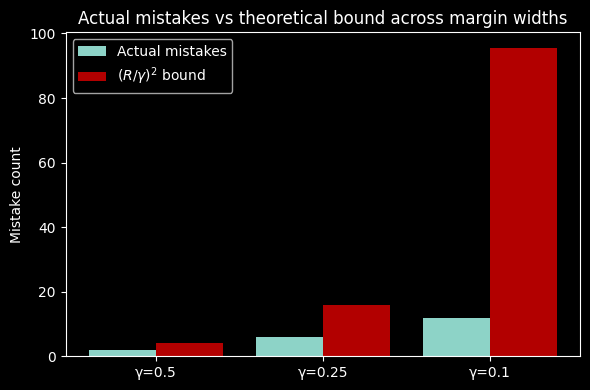

In [59]:
# Run for three margin widths to see how the bound scales with gamma
gammas = [0.5, 0.25, 0.1]
results = {}
for g in gammas:
    print(f"γ = {g}")
    mistakes, bound = run_convergence_proof(gamma=g, R=1.0, n_samples=300, seed=0)
    results[g] = (mistakes, bound)
    print()

# Summary: actual mistakes vs (R/γ)^2 bound across gammas
fig, ax = plt.subplots(figsize=(6, 4))
labels  = [f"γ={g}" for g in gammas]
actuals = [results[g][0] for g in gammas]
bounds  = [results[g][1] for g in gammas]
x = np.arange(len(gammas))
ax.bar(x - 0.2, actuals, 0.4, label="Actual mistakes")
ax.bar(x + 0.2, bounds,  0.4, label="$(R/γ)^2$ bound", alpha=0.7, color="red")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mistake count")
ax.set_title("Actual mistakes vs theoretical bound across margin widths")
ax.legend()
plt.tight_layout()
plt.show()